In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval
import matplotlib.gridspec as gridspec 
import os
from pathlib import Path

In [2]:
# load data from binary raw file
def read_raw(raw_file):
    return np.fromfile(raw_file, dtype=np.uint8)

def process_data(data, nsamples, nchans=4096, flip=False):
    data = data.reshape((-1, nchans)).T
    if flip:
        data = np.flip(data, axis=1)
    # plot the data
    data1 = data[:, :nsamples]  # first 1024 time samples
    return data1

def plot_raw(data1, title):
    dt = 1.31072e-3
    org_time_series = data1.sum(axis=0)  # shape: (n_time,)
    org_freq_series = data1.sum(axis=1)/len(data1[0])  # shape: (n_freq,)
    frequencies = [i for i in range(1,len(org_freq_series)+1)]
    times = [i*dt for i in range(1,len(org_time_series)+1)]
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(data1)

    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(nrows=2, ncols=2, width_ratios=[20, 4], height_ratios=[4, 1], wspace=0.005, hspace=0.005 )

    # Dynamic spectrum plot
    ax0 = fig.add_subplot(gs[0, 0])
    im = ax0.imshow(data1, aspect='auto', cmap='viridis',
                    extent=[times[0],times[-1], frequencies[-1], frequencies[0]], vmin=vmin, vmax=vmax)
    # ax0.set_ylim(2500,3000)
    
    # Time series plot
    ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
    ax1.plot(times, org_time_series/4096,  color='black', linewidth=1)
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Power")

    # Frequency series plot
    ax2 = fig.add_subplot(gs[0, 1], sharey=ax0)
    ax2.plot(org_freq_series, frequencies, color='black', linewidth=1)
    ax2.set_xlabel("Power")
    ax2.yaxis.tick_right()
    ax2.yaxis.set_label_position('right')
    ax2.set_ylabel("Frequency channel")
    ax2.set_xlim(max(0,np.unique(org_freq_series)[1]), )

    cax = fig.add_axes([0.055, 0.28, 0.01, 0.6])
    cbar = fig.colorbar(im, cax=cax, orientation='vertical')
    cbar.set_label("Power")
    cbar.ax.yaxis.set_ticks_position('left')
    cbar.ax.yaxis.set_label_position('left')
    
    plt.suptitle(title)
    plt.show()

def plot_histogram(data2):
    int_vals = data2.flatten()
    plt.hist(int_vals, bins=100)
    plt.xlabel('Intensity Values')
    plt.ylabel('Number of Occurrences')
    plt.title('Histogram of Intensity Values')
    plt.show()


In [3]:
data_1 = read_raw('BM26.fil.raw')
print("Data loaded")

Data loaded


In [4]:
time_samples = 4096
data1 = process_data(data_1, time_samples)

Data:


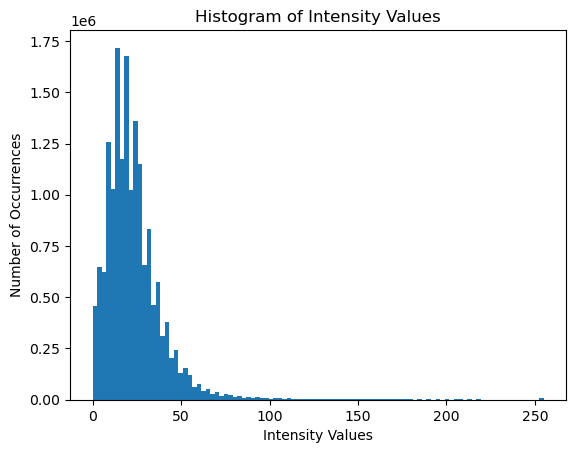

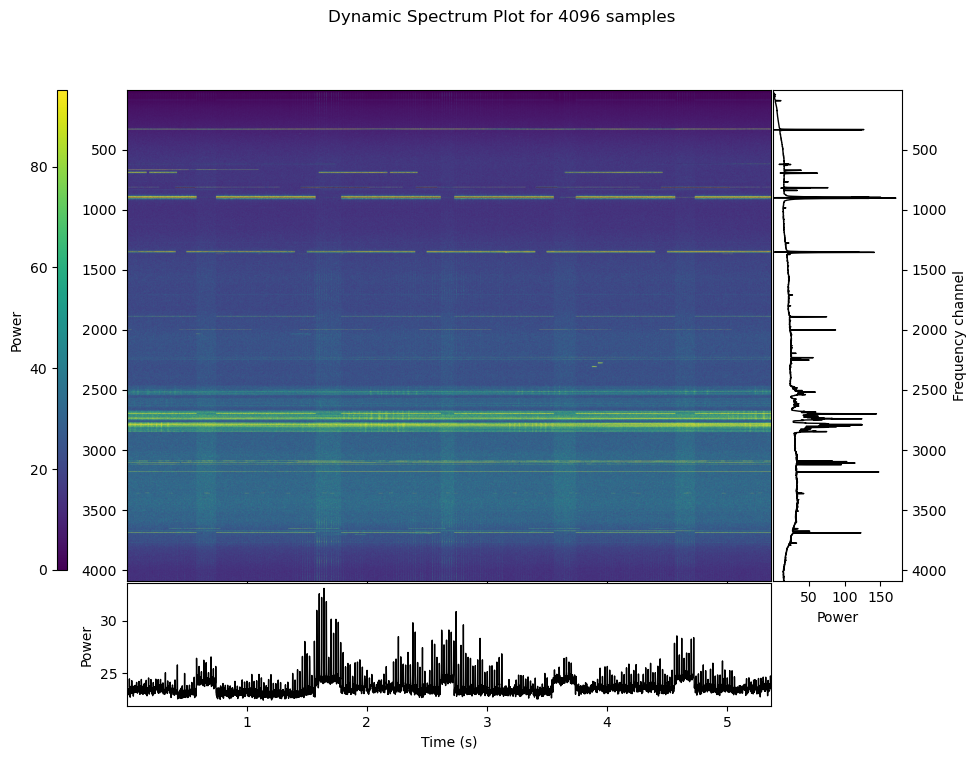

In [6]:
print("Data:")
plot_histogram(data1)
plot_raw(data1, f'Dynamic Spectrum Plot for {time_samples} samples')